In [3]:
# Check if multiple packages are installed
packages <- c("sf", "ggplot2", "dplyr", "classInt","RColorBrewer","rgeoda")

# show only missing packages
missing_packages <- packages[!packages %in% installed.packages()[,1]]
print(missing_packages)

[1] "sf"       "classInt" "rgeoda"  


In [4]:
# Installing
install.packages(c("sf", "classInt", "rgeoda"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘wk’, ‘proxy’, ‘s2’, ‘units’, ‘e1071’, ‘BH’




In [ ]:
library(sf)
library(ggplot2)
library(dplyr)
library(classInt)
library(RColorBrewer)
library(rgeoda)

Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.3.1; sf_use_s2() is TRUE


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: digest



# Load Data

In [ ]:
linkMap <- "https://github.com/MagallanesAtAlacip/datafiles/raw/main/mapaProvCovid.gpkg"

# Read GeoJSON (equivalent to gpd.read_file)
mapaProvCovid <- sf::read_sf(linkMap)

# Check structure (equivalent to .info())
str(mapaProvCovid)

sf [196 × 9] (S3: sf/tbl_df/tbl/data.frame)
 $ DEPARTAMEN     : chr [1:196] "AMAZONAS" "AMAZONAS" "AMAZONAS" "AMAZONAS" ...
 $ PROVINCIA      : chr [1:196] "CHACHAPOYAS" "BAGUA" "BONGARA" "CONDORCANQUI" ...
 $ PROV2          : chr [1:196] "CHACHAPOYAS" "BAGUA" "BONGARA" "CONDORCANQUI" ...
 $ fallecidos_2020: num [1:196] 61 268 25 78 20 9 130 476 2 5 ...
 $ positivos_2020 : num [1:196] 2166 8037 387 3465 452 ...
 $ fallecidos_2021: num [1:196] 191 153 43 26 63 46 180 576 20 25 ...
 $ positivos_2021 : num [1:196] 4647 3367 972 551 1085 ...
 $ areaKm2        : num [1:196] 2907 5794 2833 17865 3307 ...
 $ geom           :sfc_MULTIPOLYGON of length 196; first list element: List of 1
  ..$ :List of 1
  .. ..$ : num [1:3283, 1:2] 529199 529342 529421 529783 529939 ...
  ..- attr(*, "class")= chr [1:3] "XY" "MULTIPOLYGON" "sfg"
 - attr(*, "sf_column")= chr "geom"
 - attr(*, "agr")= Factor w/ 3 levels "constant","aggregate",..: NA NA NA NA NA NA NA NA
  ..- attr(*, "names")= chr [1:8] "DEPARTAM

In [ ]:
# Check first rows (equivalent to .head())
print(head(mapaProvCovid))


Simple feature collection with 6 features and 8 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 419754.2 ymin: 1317701 xmax: 595017.3 ymax: 1760070
Projected CRS: PSAD56 / Peru central zone
# A tibble: 6 × 9
  DEPARTAMEN PROVINCIA      PROV2 fallecidos_2020 positivos_2020 fallecidos_2021
  <chr>      <chr>          <chr>           <dbl>          <dbl>           <dbl>
1 AMAZONAS   CHACHAPOYAS    CHAC…              61           2166             191
2 AMAZONAS   BAGUA          BAGUA             268           8037             153
3 AMAZONAS   BONGARA        BONG…              25            387              43
4 AMAZONAS   CONDORCANQUI   COND…              78           3465              26
5 AMAZONAS   LUYA           LUYA               20            452              63
6 AMAZONAS   RODRIGUEZ DE … RODR…               9            110              46
# ℹ 3 more variables: positivos_2021 <dbl>, areaKm2 <dbl>,
#   geom <MULTIPOLYGON [m]>


In [ ]:
# Check CRS (equivalent to .crs)
st_crs(mapaProvCovid)


Coordinate Reference System:
  User input: PSAD56 / Peru central zone 
  wkt:
PROJCRS["PSAD56 / Peru central zone",
    BASEGEOGCRS["PSAD56",
        DATUM["Provisional South American Datum 1956",
            ELLIPSOID["International 1924",6378388,297,
                LENGTHUNIT["metre",1]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433]],
        ID["EPSG",4248]],
    CONVERSION["Peru central zone",
        METHOD["Transverse Mercator",
            ID["EPSG",9807]],
        PARAMETER["Latitude of natural origin",-9.5,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8801]],
        PARAMETER["Longitude of natural origin",-76,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8802]],
        PARAMETER["Scale factor at natural origin",0.99932994,
            SCALEUNIT["unity",1],
            ID["EPSG",8805]],
        PARAMETER["False easting",720000,
            LENGTHUNIT["metre",1],
            ID["EPS

In [ ]:
# Check if projected (equivalent to .crs.is_projected)
st_is_longlat(mapaProvCovid)  # TRUE if geographic (not projected)


[1] FALSE

In [ ]:
# If reprojection needed:
# mapaProvCovid_24892 <- st_transform(mapaProvCovid, 24892)


# Calculate Variables

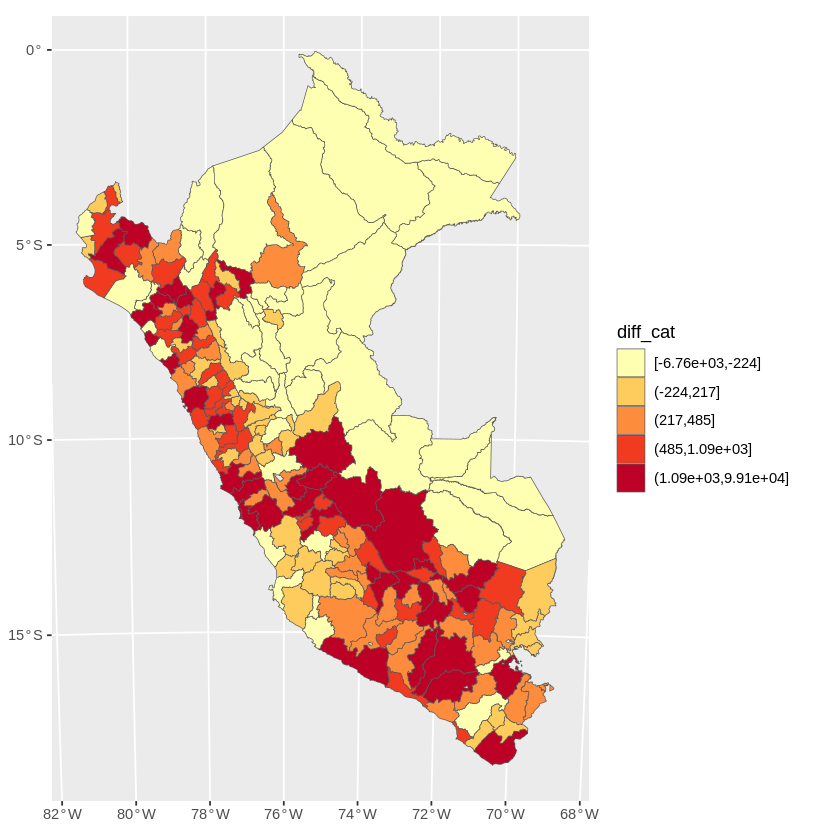

In [ ]:
# Difference (non-normalized - wrong decision
mapaProvCovid <- mapaProvCovid %>%
  mutate(diffPOS_20_21 = positivos_2021 - positivos_2020)

# 1. Calculate breaks
breaks_nonor <- classIntervals(mapaProvCovid$diffPOS_20_21,
                         n = 5,
                         style = "quantile")$brks

# 2. Create categorical variable
mapaProvCovid$diff_cat <- cut(mapaProvCovid$diffPOS_20_21,
                              breaks = breaks_nonor,
                              include.lowest = TRUE)

# 3. Plot with ggplot
ggplot(mapaProvCovid) +
  geom_sf(aes(fill = diff_cat)) +
  scale_fill_brewer(palette = "YlOrRd")

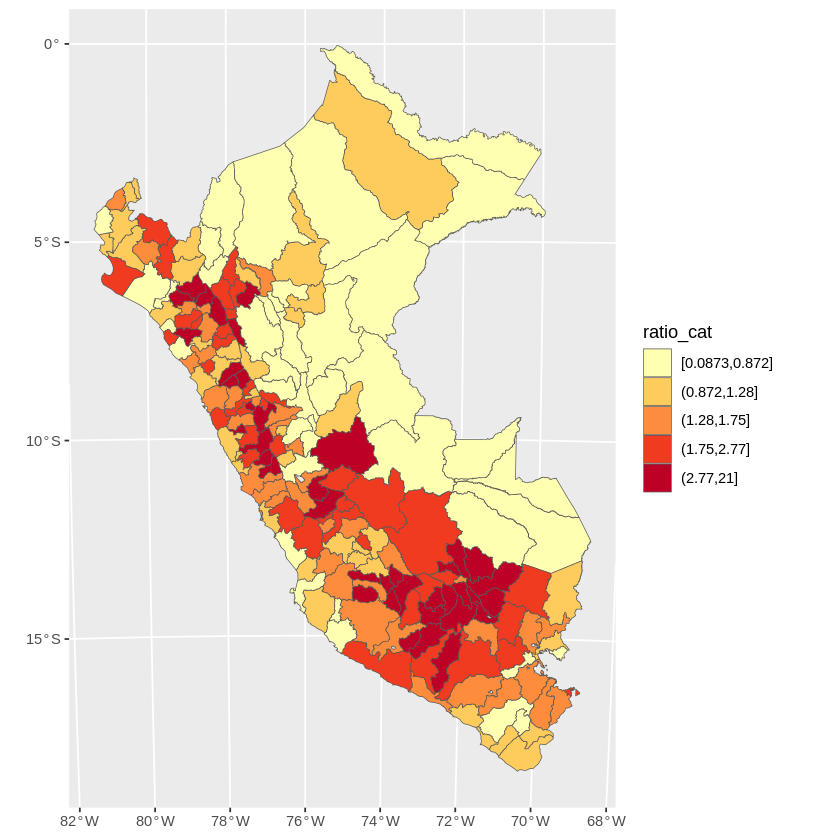

In [ ]:
# Ratio - (normalized (right decision)
mapaProvCovid <- mapaProvCovid %>%
  mutate(ratioPOS_20_21 = positivos_2021 / positivos_2020)

# 1. Calculate breaks
breaks_nor <- classIntervals(mapaProvCovid$ratioPOS_20_21,
                         n = 5,
                         style = "quantile")$brks

# 2. Create categorical variable
mapaProvCovid$ratio_cat <- cut(mapaProvCovid$ratioPOS_20_21,
                              breaks = breaks_nor,
                              include.lowest = TRUE)

# 3. Plot with ggplot
ggplot(mapaProvCovid) +
  geom_sf(aes(fill = ratio_cat)) +
  scale_fill_brewer(palette = "YlOrRd")

In [ ]:
# Drop diff column (we do not need the non nomalized)
mapaProvCovid <- mapaProvCovid %>%
  select(-diffPOS_20_21)

# currently
head(mapaProvCovid)


ERROR while rich displaying an object: Error in loadNamespace(x): there is no package called ‘geojsonio’

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = 

DEPARTAMEN,PROVINCIA,PROV2,fallecidos_2020,positivos_2020,fallecidos_2021,positivos_2021,areaKm2,geom,diff_cat,ratioPOS_20_21,ratio_cat
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<MULTIPOLYGON [m]>,<fct>,<dbl>,<fct>
AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,61,2166,191,4647,2906.932,MULTIPOLYGON (((529198.8 14...,"(1.09e+03,9.91e+04]",2.1454294,"(1.75,2.77]"
AMAZONAS,BAGUA,BAGUA,268,8037,153,3367,5793.966,MULTIPOLYGON (((429663.3 15...,"[-6.76e+03,-224]",0.4189374,"[0.0873,0.872]"
AMAZONAS,BONGARA,BONGARA,25,387,43,972,2832.855,MULTIPOLYGON (((528780.4 15...,"(485,1.09e+03]",2.5116279,"(1.75,2.77]"
AMAZONAS,CONDORCANQUI,CONDORCANQUI,78,3465,26,551,17864.534,MULTIPOLYGON (((518879.1 17...,"[-6.76e+03,-224]",0.1590188,"[0.0873,0.872]"
AMAZONAS,LUYA,LUYA,20,452,63,1085,3306.793,MULTIPOLYGON (((484444 1437...,"(485,1.09e+03]",2.4004425,"(1.75,2.77]"
AMAZONAS,RODRIGUEZ DE MENDOZA,RODRIGUEZ DE MENDOZA,9,110,46,1177,2580.588,MULTIPOLYGON (((560404 1421...,"(485,1.09e+03]",10.7000000,"(2.77,21]"


In [ ]:
# Summary statistics (equivalent to .describe())
summary(mapaProvCovid)

     DEPARTAMEN      PROVINCIA         PROV2     fallecidos_2020   
 Length   :196   Length   :196   Length   :196   Min.   :    2.00  
 N.unique : 26   N.unique :196   N.unique :196   1st Qu.:   23.75  
 N.blank  :  0   N.blank  :  0   N.blank  :  0   Median :   60.50  
 Min.nchar:  3   Min.nchar:  3   Min.nchar:  3   Mean   :  485.90  
 Max.nchar: 18   Max.nchar: 25   Max.nchar: 25   3rd Qu.:  190.00  
                                                 Max.   :39328.00  
 positivos_2020     fallecidos_2021    positivos_2021        areaKm2       
 Min.   :    18.0   Min.   :    4.00   Min.   :    63.0   Min.   :  140.2  
 1st Qu.:   337.8   1st Qu.:   46.75   1st Qu.:   639.5   1st Qu.: 1874.5  
 Median :   859.0   Median :  103.00   Median :  1197.0   Median : 3160.8  
 Mean   :  4938.1   Mean   :  550.48   Mean   :  6301.6   Mean   : 6574.6  
 3rd Qu.:  2443.0   3rd Qu.:  317.00   3rd Qu.:  3317.5   3rd Qu.: 5570.1  
 Max.   :387132.0   Max.   :43120.00   Max.   :486207.0   Max.   :76

# Discretizing



## Using Quantiles

In [ ]:
# Create quantile breaks (equivalent to mc.Quantiles)
qn_ratioPOS <- classIntervals(mapaProvCovid$ratioPOS_20_21, n = 5, style = "quantile")


In [ ]:
# View breaks
qn_ratioPOS

style: quantile
[0.08732158,0.8716774)   [0.8716774,1.281746)    [1.281746,1.747253) 
                    39                     39                     39 
   [1.747253,2.770992)    [2.770992,21.02778] 
                    39                     40 

## User-Defined Bins

In [ ]:
my_bins <- c(0.5, 0.8, 1.0, 1.5)

# User-defined classification
user_ratioPOS <- classIntervals(mapaProvCovid$ratioPOS_20_21,
                                style = "fixed",
                                fixedBreaks = c(min(mapaProvCovid$ratioPOS_20_21, na.rm = TRUE),
                                                my_bins,
                                                max(mapaProvCovid$ratioPOS_20_21, na.rm = TRUE)))

user_ratioPOS


style: fixed
[0.08732158,0.5)        [0.5,0.8)          [0.8,1)          [1,1.5) 
              14               19               15               48 
  [1.5,21.02778] 
             100 

In [ ]:
# Assign groups
mapaProvCovid <- mapaProvCovid %>%
  mutate(ratioPOS_20_21_group = cut(ratioPOS_20_21,
                                    breaks = user_ratioPOS$brks,
                                    labels = FALSE,
                                    include.lowest = TRUE))

print(head(mapaProvCovid))


Simple feature collection with 6 features and 12 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 419754.2 ymin: 1317701 xmax: 595017.3 ymax: 1760070
Projected CRS: PSAD56 / Peru central zone
# A tibble: 6 × 13
  DEPARTAMEN PROVINCIA      PROV2 fallecidos_2020 positivos_2020 fallecidos_2021
  <chr>      <chr>          <chr>           <dbl>          <dbl>           <dbl>
1 AMAZONAS   CHACHAPOYAS    CHAC…              61           2166             191
2 AMAZONAS   BAGUA          BAGUA             268           8037             153
3 AMAZONAS   BONGARA        BONG…              25            387              43
4 AMAZONAS   CONDORCANQUI   COND…              78           3465              26
5 AMAZONAS   LUYA           LUYA               20            452              63
6 AMAZONAS   RODRIGUEZ DE … RODR…               9            110              46
# ℹ 7 more variables: positivos_2021 <dbl>, areaKm2 <dbl>,
#   geom <MULTIPOLYGON [m]>, diff_cat <fct>, ratioPOS_20_

## Recode Bin Labels

In [ ]:

TheLabels <- c('1_Best', '2_veryGood', '3_Good', '4_Bad', '5_Worst')

mapaProvCovid <- mapaProvCovid %>%
  mutate(ratioPOS_20_21_group = factor(ratioPOS_20_21_group,
                                       levels = 1:5,
                                       labels = TheLabels))

print(head(mapaProvCovid))


Simple feature collection with 6 features and 12 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 419754.2 ymin: 1317701 xmax: 595017.3 ymax: 1760070
Projected CRS: PSAD56 / Peru central zone
# A tibble: 6 × 13
  DEPARTAMEN PROVINCIA      PROV2 fallecidos_2020 positivos_2020 fallecidos_2021
  <chr>      <chr>          <chr>           <dbl>          <dbl>           <dbl>
1 AMAZONAS   CHACHAPOYAS    CHAC…              61           2166             191
2 AMAZONAS   BAGUA          BAGUA             268           8037             153
3 AMAZONAS   BONGARA        BONG…              25            387              43
4 AMAZONAS   CONDORCANQUI   COND…              78           3465              26
5 AMAZONAS   LUYA           LUYA               20            452              63
6 AMAZONAS   RODRIGUEZ DE … RODR…               9            110              46
# ℹ 7 more variables: positivos_2021 <dbl>, areaKm2 <dbl>,
#   geom <MULTIPOLYGON [m]>, diff_cat <fct>, ratioPOS_20_

### Plotting binned var

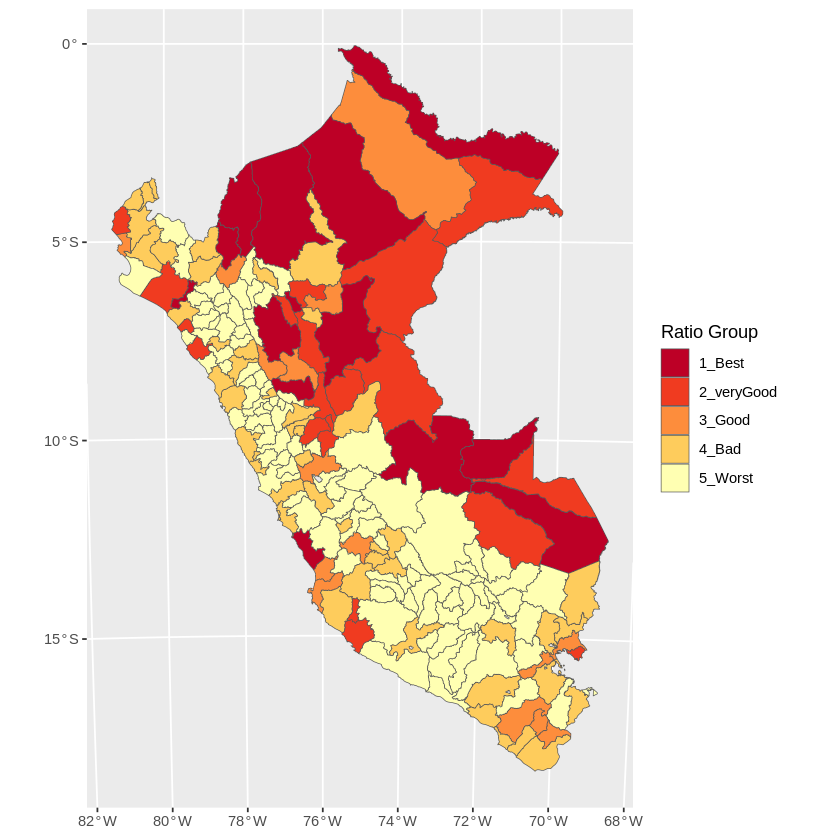

In [ ]:

# ggplot2 doesn't have built-in _r palettes, so 'direction = -1'
ggplot(mapaProvCovid) +
  geom_sf(aes(fill = ratioPOS_20_21_group)) +
  scale_fill_brewer(palette = "YlOrRd",
                    direction = -1,
                    name = "Ratio Group")

### Colorblindness safe options:

* viridis

In [ ]:
install.packages("viridis")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘gridExtra’




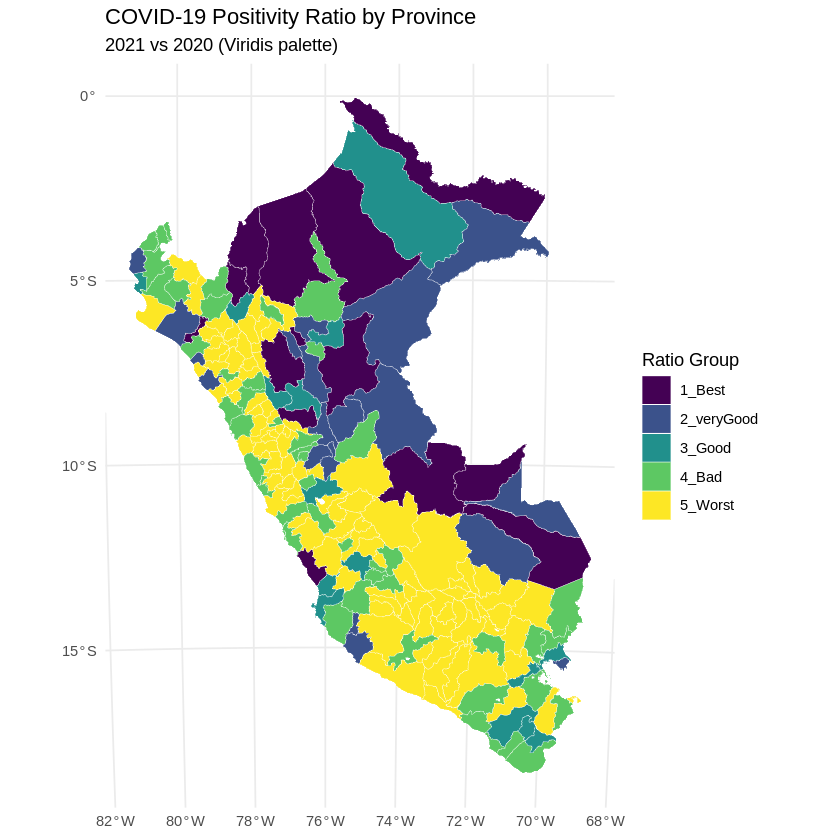

In [ ]:
library(viridis)

ggplot(mapaProvCovid) +
  geom_sf(aes(fill = ratioPOS_20_21_group), color = "white", size = 0.1) +
  scale_fill_viridis_d(option = "viridis",
                      #  direction = -1,
                       name = "Ratio Group") +
  theme_minimal() +
  labs(title = "COVID-19 Positivity Ratio by Province",
       subtitle = "2021 vs 2020 (Viridis palette)")

* Cividis

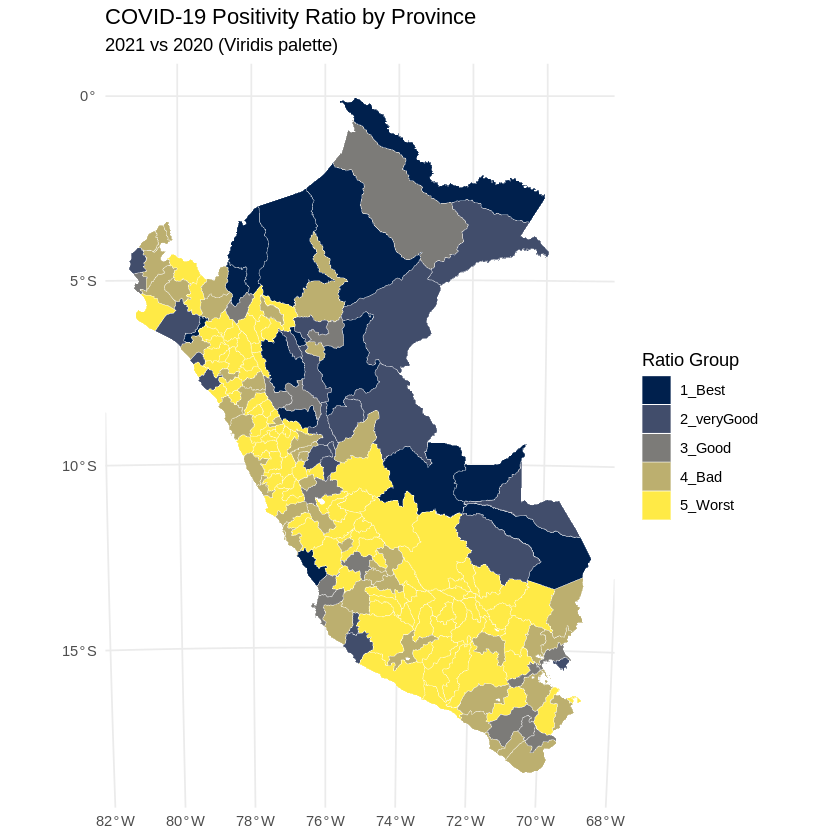

In [ ]:
ggplot(mapaProvCovid) +
  geom_sf(aes(fill = ratioPOS_20_21_group), color = "white", size = 0.1) +
  scale_fill_viridis_d(option = "cividis",
                      #  direction = -1,
                       name = "Ratio Group") +
  theme_minimal() +
  labs(title = "COVID-19 Positivity Ratio by Province",
       subtitle = "2021 vs 2020 (Viridis palette)")

* Diverging

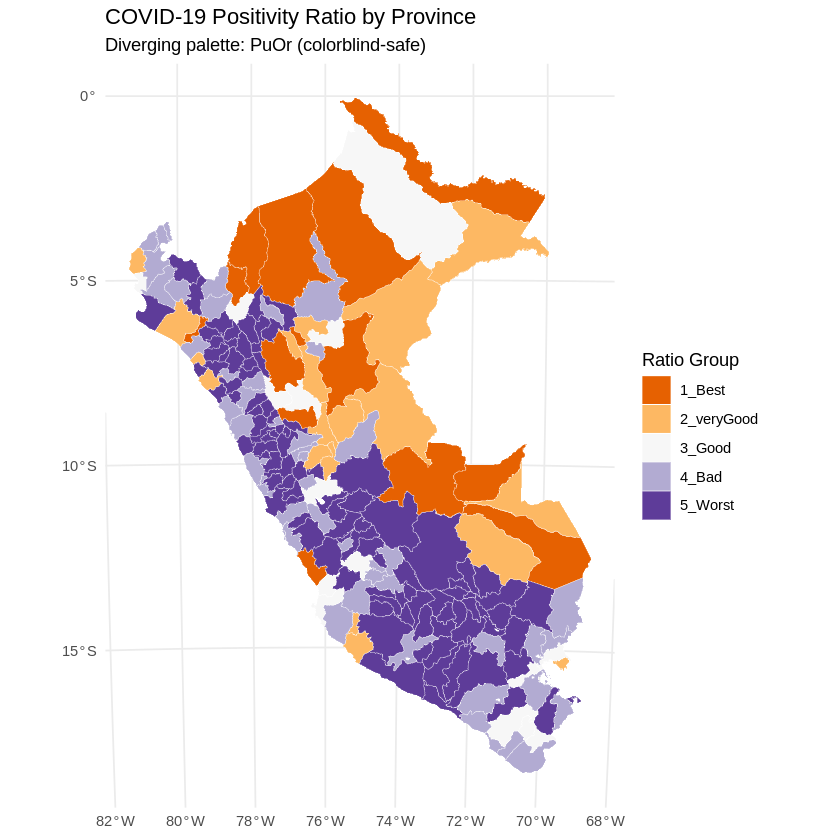

In [ ]:
ggplot(mapaProvCovid) +
  geom_sf(aes(fill = ratioPOS_20_21_group), color = "white", size = 0.1) +
  scale_fill_brewer(
    palette = "PuOr",  # Diverging colorblind-safe palette
    # direction = -1,    # Reverse: Orange = Best, Purple = Worst
    name = "Ratio Group"
  ) +
  theme_minimal() +
  labs(title = "COVID-19 Positivity Ratio by Province",
       subtitle = "Diverging palette: PuOr (colorblind-safe)")

###  Interactive Map

This is not as easy as in Python!

# Spatial Autocorrelation (Moran's I & LISA)

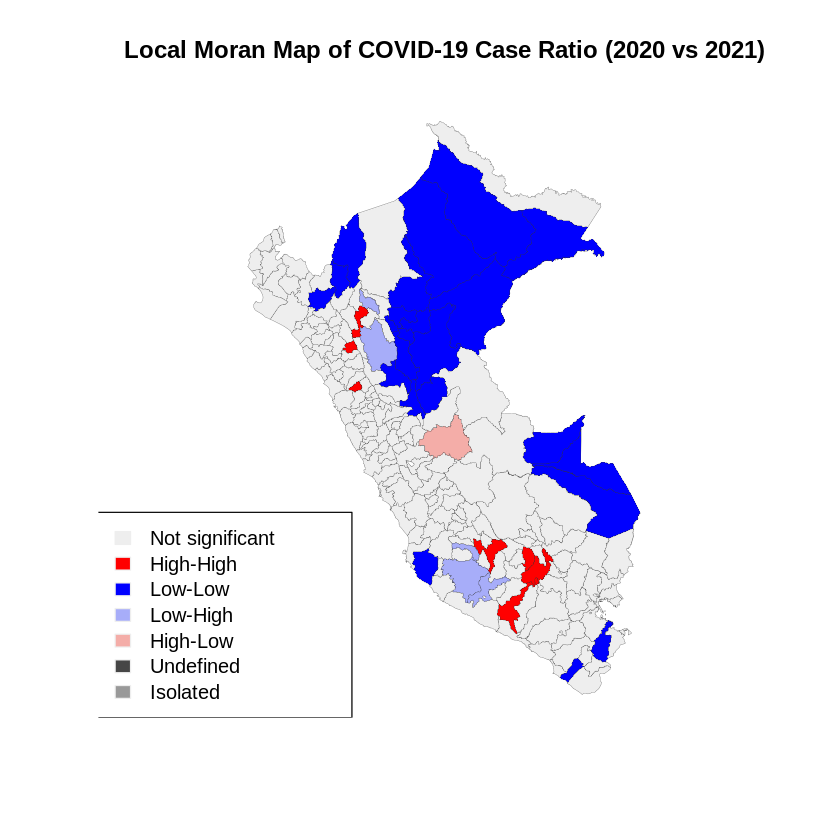

In [ ]:
# --- Load Required Libraries ---
library(sf)
library(rgeoda)

# --- Your Data ---
# Assuming mapaProvCovid is already loaded as an sf object
y <- mapaProvCovid$ratioPOS_20_21

# --- Step 1: Remove NAs (if any) ---
to_clust <- mapaProvCovid %>%
  filter(!is.na(ratioPOS_20_21))

# --- Step 2: Create Queen Weights ---
queen_wts <- queen_weights(to_clust)

# --- Step 3: Calculate Local Moran's I ---
lisa <- local_moran(queen_wts, st_drop_geometry(to_clust["ratioPOS_20_21"]))

# --- Step 4: Extract Results (the simple way) ---
lisa_colors <- lisa_colors(lisa)
lisa_labels <- lisa_labels(lisa)
lisa_clusters <- lisa_clusters(lisa)

# --- Step 5: Create the Cluster Map (the simple way) ---
# Plot the map using base R graphics
plot(st_geometry(to_clust),
     col = sapply(lisa_clusters, function(x) {
       return(lisa_colors[[x + 1]])  # +1 because R is 1-indexed
     }),
     border = "#333333",
     lwd = 0.2)

# Add title and legend
title(main = "Local Moran Map of COVID-19 Case Ratio (2020 vs 2021)")
legend('bottomleft',
       legend = lisa_labels,
       fill = lisa_colors,
       border = "#eeeeee")